In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def interpolate(c, x, x0):
    """Evaluates Newton's polynomial at x0"""
    n = len(x) - 1
    y0 = c[n]
    for i in range(1, n + 1):
        y0 = (x0 - x[n-i]) * y0 + c[n-i]
    return y0

In [44]:
def coeff(x, y):
    """Calculates Newton's polynomial coefficients"""
    n = len(x)
    c = y.copy()
    # for i in range(1, n):
    #     c[i:] = (c[i:] - c[i-1:n-1]) / (x[i:] - x[:n-i])
    for i in range(1, n):
        c[i:] = (c[i:] - c[i-1]) / (x[i:] - x[i-1])
    return c

In [45]:
def f(x):
    return 1.0 / (1.0 + 25 * x**2)

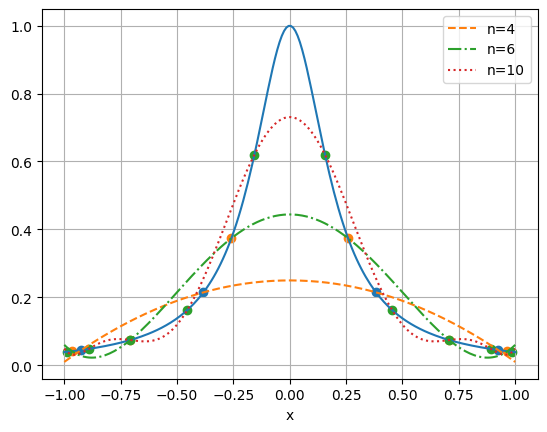

In [49]:
a = -1.0
b = 1.0
x1 = np.linspace(a, b, 200)
y1 = f(x1)
plt.plot(x1, y1)
nList = [4, 6, 10]
sglist = ['--', '-.', ':']
for k in range(len(nList)):
    n = nList[k]
    
    # x = np.linspace(a, b, n + 1)

    # гиперболический тангенс
    # xi = np.linspace(0.0, 1.0, n + 1)
    # stretched = 0.5 * (1.0 + np.tanh(3.0 * (xi - 0.5)) / np.tanh(0.5 * 3.0))
    # x = a + (b - a) * stretched

    # узлы Чебышёва
    x = np.asarray([0.5 * (a + b) + 0.5 * (b - a) * np.cos(0.5 * np.pi * (2 * k - 1) / n) for k in range(1, n + 1)])
    
    y = f(x)
    plt.scatter(x, y, marker='o')
    c = coeff(x, y)
    y1 = interpolate(c, x, x1)
    plt.plot(x1, y1, sglist[k], label=f"n={n}")
plt.xlabel('x')
plt.grid(True)
plt.legend()
